# Credit Risk Modelling — Part 3: Feature Engineering & Preprocessing
---
**Objective:** Transform the raw data into a clean, model-ready feature matrix.  
Every decision here is made with domain knowledge from Part 2 (EDA) and with train/test hygiene in mind.

**Steps in this notebook:**
1. Setup & data reload
2. Step 1 — Missingness indicator flags
3. Step 2 — Numeric imputation (median)
4. Step 3 — Categorical encoding (one-hot)
5. Step 4 — Column alignment (train ↔ test)
6. Step 5 — Class imbalance handling (sample weights)
7. Preprocessing pipeline (reusable function)
8. Validation — post-processing checks
9. Visualisations — before vs after
10. Save preprocessing artefacts
11. Summary

---
## 1 — Setup & Data Reload

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import re
import json
import joblib
import warnings
from pathlib import Path
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

BLUE, ORANGE, GREEN, RED, PURPLE = "#4472C4","#ED7D31","#70AD47","#C00000","#7030A0"
TRAIN_X = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - X_train.csv"
TEST_X = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - X_test.csv"

TRAIN_Y = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - Y_train.csv"
TEST_Y = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - Y_test.csv"


X_train_raw = pd.read_csv(TRAIN_X)
y_train_raw = pd.read_csv(TRAIN_Y)
X_test_raw  = pd.read_csv(TEST_X)
y_test_raw  = pd.read_csv(TEST_Y)

train = X_train_raw.merge(y_train_raw, on="account_id")
test  = X_test_raw.merge(y_test_raw,   on="account_id")

feature_cols = [c for c in X_train_raw.columns if c != "account_id"]
cat_cols     = [c for c in feature_cols if str(X_train_raw[c].dtype) in ("object","str")]
num_cols     = [c for c in feature_cols if c not in cat_cols]

families = {}
for c in feature_cols:
    m = re.match(r"^([a-z_]+?)_\d+$", c)
    families.setdefault(m.group(1) if m else "other", []).append(c)

print(f"Train raw : {train.shape}   Test raw : {test.shape}")
print(f"Numeric features  : {len(num_cols)}")
print(f"Categorical feats : {len(cat_cols)} → {cat_cols}")
print("\n✓ Data loaded — ready for feature engineering")

Train raw : (28397, 102)   Test raw : (4000, 102)
Numeric features  : 98
Categorical feats : 2 → ['financial_situation_4', 'financial_situation_5']

✓ Data loaded — ready for feature engineering


---
## Step 1 — Missingness Indicator Flags

### Why?
From EDA (Part 2) we saw that **NaN is not random** — it means an event never occurred  
(e.g. `recency_1 = NaN` → customer has never had a late payment of this type).

This is **informative missingness**: the absence of a value carries predictive signal about default risk.

### Decision rule
Add a binary flag `{feature}_is_missing = 1` for every numeric feature  
with **more than 5% missing values** in the training set.

> Features with <5% missing have too few NaN rows to learn from reliably.

In [3]:
# ── Identify features that exceed the 5% missing threshold ──────
MISSING_THRESHOLD = 0.05

miss_pct = X_train_raw[num_cols].isnull().mean()   # proportion, not %
flag_cols = miss_pct[miss_pct > MISSING_THRESHOLD].index.tolist()

print(f"Missing threshold : >{MISSING_THRESHOLD*100:.0f}%")
print(f"Total numeric     : {len(num_cols)}")
print(f"Will get flag     : {len(flag_cols)}")
print(f"Will NOT get flag : {len(num_cols) - len(flag_cols)}  (missing rate ≤{MISSING_THRESHOLD*100:.0f}%)")

# Show breakdown by feature family
print("\nFlag count by feature family:")
for fam, cols in sorted(families.items()):
    num_in_fam   = [c for c in cols if c in num_cols]
    flagged      = [c for c in num_in_fam if c in flag_cols]
    if num_in_fam:
        print(f"  {fam:<25}: {len(flagged):>3}/{len(num_in_fam)} features flagged  "
              f"(avg missing: {miss_pct[num_in_fam].mean()*100:.1f}%)")

Missing threshold : >5%
Total numeric     : 98
Will get flag     : 79
Will NOT get flag : 19  (missing rate ≤5%)

Flag count by feature family:
  balance                  :  22/24 features flagged  (avg missing: 37.9%)
  credit_limit             :   3/3 features flagged  (avg missing: 32.6%)
  demand_for_credit        :   1/1 features flagged  (avg missing: 33.6%)
  financial_situation      :   2/3 features flagged  (avg missing: 36.0%)
  recency                  :   6/12 features flagged  (avg missing: 28.2%)
  repayment_history        :  22/31 features flagged  (avg missing: 25.6%)
  score                    :   0/1 features flagged  (avg missing: 0.0%)
  spend_behaviour          :   5/5 features flagged  (avg missing: 62.2%)
  utilization              :  18/18 features flagged  (avg missing: 39.1%)


In [4]:
# ── Show that missingness flags carry predictive signal ──────────
flag_signal = []
for col in flag_cols:
    dr_null     = train[train[col].isnull()]["label"].mean() * 100
    dr_not_null = train[train[col].notna()]["label"].mean() * 100
    diff        = dr_null - dr_not_null
    flag_signal.append({
        "feature"         : col,
        "miss_pct"        : round(miss_pct[col]*100, 1),
        "dr_when_null_%"  : round(dr_null, 2),
        "dr_when_present_%": round(dr_not_null, 2),
        "diff_pp"         : round(diff, 2)
    })

sig_df = pd.DataFrame(flag_signal).sort_values("diff_pp", key=abs, ascending=False)
print("Top 20 missingness flags ranked by |default rate difference|:")
print(sig_df.head(20).to_string(index=False))
print(f"\n→ {(sig_df['diff_pp']>0).sum()} flags: NaN → HIGHER risk")
print(f"→ {(sig_df['diff_pp']<0).sum()} flags: NaN → LOWER risk")
print(f"→ All {len(flag_cols)} flags carry directional information")

Top 20 missingness flags ranked by |default rate difference|:
             feature  miss_pct  dr_when_null_%  dr_when_present_%  diff_pp
          balance_12       8.3           21.01               4.40    16.61
 repayment_history_4       5.2           21.46               4.93    16.54
       utilization_6       8.3           20.90               4.41    16.48
          balance_10       6.0           20.68               4.84    15.84
           balance_8       6.3           20.49               4.80    15.69
           balance_1       6.3           20.49               4.80    15.69
          balance_14       5.8           20.20               4.90    15.29
           balance_2      11.9           18.44               4.08    14.35
          balance_16       7.0           19.12               4.78    14.34
           recency_1      14.8           17.03               3.83    13.20
repayment_history_26      15.6           16.74               3.76    12.98
repayment_history_14      15.6        

---
## Step 2 — Numeric Imputation

### Why median (not mean)?
- Features contain intentionally added noise → some outlier values
- Median is robust to extreme values; mean would be pulled
- Tree-based models are imputation-robust, but clean imputation helps linear models

### Critical rule
**Fit the median on training data only. Apply to both train and test.**  
Fitting on combined data would leak test information into the imputation values.

In [5]:
# ── Compute medians on train only ────────────────────────────────
train_medians = train[num_cols].median()

print("Verifying no median is NaN:")
print(f"  NaN medians: {train_medians.isnull().sum()}  ✓" if train_medians.isnull().sum()==0
      else f"  ✗ {train_medians.isnull().sum()} NaN medians!")

print("\nMedian statistics across all numeric features:")
m_stats = train_medians.describe()
for k, v in m_stats.items():
    print(f"  {k:<8}: {v:>12.4f}")

# Check a few specific examples
examples = ["score_1", "utilization_1", "recency_1", "balance_1", "repayment_history_1"]
print("\nExample medians (train):")
for col in examples:
    if col in train_medians:
        null_pct = train[col].isnull().mean()*100
        print(f"  {col:<30}: median={train_medians[col]:>10.4f}  (missing={null_pct:.1f}%)")

Verifying no median is NaN:
  NaN medians: 0  ✓

Median statistics across all numeric features:
  count   :      98.0000
  mean    :     491.7516
  std     :    1110.7871
  min     :       0.0000
  25%     :       0.9544
  50%     :       6.5750
  75%     :     255.5066
  max     :    4894.3460

Example medians (train):
  score_1                       : median=  686.6959  (missing=0.0%)
  utilization_1                 : median=   39.7053  (missing=21.6%)
  recency_1                     : median=   73.8357  (missing=14.8%)
  balance_1                     : median=   11.0276  (missing=6.3%)
  repayment_history_1           : median=   56.4998  (missing=68.1%)


In [9]:
# ── Show imputation impact: train vs test median comparison ──────
test_medians = test[num_cols].median()

med_compare = pd.DataFrame({
    "train_median": train_medians,
    "test_median" : test_medians,
    "diff_pct"    : ((test_medians - train_medians) / (train_medians.abs() + 1e-9) * 100)
})
med_compare["abs_diff_pct"] = med_compare["diff_pct"].abs()
large_diff = med_compare[med_compare["abs_diff_pct"] > 10].sort_values("abs_diff_pct", ascending=False)

print(f"Features where train/test medians differ by >10%: {len(large_diff)}")
if len(large_diff) > 0:
    print(large_diff[["train_median","test_median","diff_pct"]].head(10).round(3).to_string())
else:
    print("✓ Train and test medians are consistent — no distribution shift detected")

Features where train/test medians differ by >10%: 16
                      train_median  test_median  diff_pct
repayment_history_4          0.000        0.000   156.994
repayment_history_24         0.000        0.000   -75.997
spend_behaviour_1            0.947        0.645   -31.896
utilization_5                3.097        3.981    28.556
utilization_3                3.081        3.948    28.132
repayment_history_31         0.002        0.003    21.048
balance_7                  463.651      551.138    18.869
balance_5                    2.649        2.211   -16.540
utilization_12               5.982        4.998   -16.458
utilization_9               44.586       37.887   -15.025


---
## Step 3 — Categorical Encoding (One-Hot)

### Two categorical features
- `financial_situation_4` — 13 categories (+ rare NaN → encoded as `MISSING`)
- `financial_situation_5` — 8 categories (+ rare NaN → encoded as `MISSING`)

### Why one-hot (not ordinal/label encoding)?
- We have no natural ordering between categories like `P1`, `S2`, `N3`
- One-hot encoding makes each category independently learnable
- Tree models handle the resulting sparse dummies efficiently
- We keep all categories (no `drop_first`) — avoids information loss with tree models

### NaN handling
Rather than dropping the 2 rows with NaN values, we encode them as a `MISSING` category.  
This preserves all rows and allows the model to learn from this rare pattern.

In [10]:
# ── Categorical stats before encoding ────────────────────────────
print("Categorical feature summary:")
for col in cat_cols:
    vc       = train[col].value_counts(dropna=False).sort_values(ascending=False)
    null_cnt = train[col].isnull().sum()
    print(f"\n  {col}:")
    print(f"    Unique categories : {train[col].nunique()}")
    print(f"    NaN count         : {null_cnt}")
    for cat, cnt in vc.items():
        dr = train[train[col]==cat]["label"].mean()*100 if pd.notna(cat) else train[train[col].isna()]["label"].mean()*100
        label_str = str(cat) if pd.notna(cat) else "NaN→MISSING"
        print(f"    {label_str:<12}: {cnt:>5,} rows  ({cnt/len(train)*100:.1f}%)  default={dr:.1f}%")

Categorical feature summary:

  financial_situation_4:
    Unique categories : 13
    NaN count         : 0
    P1          : 20,513 rows  (72.2%)  default=3.9%
    N1          : 2,235 rows  (7.9%)  default=11.2%
    N2          : 2,053 rows  (7.2%)  default=12.7%
    P3          : 1,686 rows  (5.9%)  default=7.9%
    S1          :   666 rows  (2.3%)  default=10.2%
    ND          :   493 rows  (1.7%)  default=11.4%
    P2          :   466 rows  (1.6%)  default=9.9%
    S2          :    93 rows  (0.3%)  default=10.8%
    S3          :    82 rows  (0.3%)  default=11.0%
    P4          :    56 rows  (0.2%)  default=7.1%
    N3          :    26 rows  (0.1%)  default=15.4%
    N4          :    22 rows  (0.1%)  default=9.1%
    S4          :     6 rows  (0.0%)  default=16.7%

  financial_situation_5:
    Unique categories : 8
    NaN count         : 0
    B           : 9,188 rows  (32.4%)  default=2.9%
    C           : 5,893 rows  (20.8%)  default=5.2%
    A           : 5,556 rows  (19.6%)

In [11]:
# ── Compute modes on TRAIN only (for NaN filling) ────────────────
train_modes = {}
for col in cat_cols:
    # We use "MISSING" as a category rather than imputing the mode
    # because NaN is rare (only 2 rows) and MISSING may be informative
    train_modes[col] = "MISSING"   # sentinel value

print("NaN strategy for categorical features:")
print("  → Fill NaN with 'MISSING' (not mode) — preserves the rare pattern")
print("  → 'MISSING' becomes its own one-hot column in the encoded matrix")
print()
for col in cat_cols:
    after_fill = train[col].fillna("MISSING")
    dummies    = pd.get_dummies(after_fill, prefix=col, drop_first=False)
    print(f"  {col}")
    print(f"    Before OHE : 1 column  ({train[col].nunique()} unique values + {train[col].isnull().sum()} NaN)")
    print(f"    After OHE  : {dummies.shape[1]} columns → {list(dummies.columns)}")

NaN strategy for categorical features:
  → Fill NaN with 'MISSING' (not mode) — preserves the rare pattern
  → 'MISSING' becomes its own one-hot column in the encoded matrix

  financial_situation_4
    Before OHE : 1 column  (13 unique values + 0 NaN)
    After OHE  : 13 columns → ['financial_situation_4_N1', 'financial_situation_4_N2', 'financial_situation_4_N3', 'financial_situation_4_N4', 'financial_situation_4_ND', 'financial_situation_4_P1', 'financial_situation_4_P2', 'financial_situation_4_P3', 'financial_situation_4_P4', 'financial_situation_4_S1', 'financial_situation_4_S2', 'financial_situation_4_S3', 'financial_situation_4_S4']
  financial_situation_5
    Before OHE : 1 column  (8 unique values + 0 NaN)
    After OHE  : 8 columns → ['financial_situation_5_A', 'financial_situation_5_B', 'financial_situation_5_C', 'financial_situation_5_D', 'financial_situation_5_E', 'financial_situation_5_F', 'financial_situation_5_G', 'financial_situation_5_H']


---
## Step 4 — Column Alignment (Train ↔ Test)

After one-hot encoding, the test set must have **exactly the same columns** as the training set.

### Why this can fail
If a category appears in train but not in test (or vice versa), the OHE columns won't match.  
We handle this by:
1. Recording the final feature column list from the processed training set
2. Adding any missing columns to the test set as **zeros**
3. Dropping any extra columns in test that don't exist in train

This is the same logic an inference script must apply when scoring new data in production.

In [12]:
# ── Preview: what columns might mismatch? ────────────────────────
train_tmp = train.copy()
test_tmp  = test.copy()

for col in cat_cols:
    train_tmp[col] = train_tmp[col].fillna("MISSING")
    test_tmp[col]  = test_tmp[col].fillna("MISSING")

train_dummies = pd.get_dummies(train_tmp, columns=cat_cols, drop_first=False)
test_dummies  = pd.get_dummies(test_tmp,  columns=cat_cols, drop_first=False)

train_feat_cols = [c for c in train_dummies.columns if c not in ["account_id","label"]]
test_feat_cols  = [c for c in test_dummies.columns  if c not in ["account_id","label"]]

only_in_train = set(train_feat_cols) - set(test_feat_cols)
only_in_test  = set(test_feat_cols)  - set(train_feat_cols)

print(f"Columns only in TRAIN (will be added to test as 0): {len(only_in_train)}")
for c in sorted(only_in_train): print(f"  + {c}")

print(f"\nColumns only in TEST  (will be dropped from test) : {len(only_in_test)}")
for c in sorted(only_in_test): print(f"  - {c}")

if len(only_in_train) == 0 and len(only_in_test) == 0:
    print("\n✓ Perfect alignment — no columns need adding or dropping")

Columns only in TRAIN (will be added to test as 0): 0

Columns only in TEST  (will be dropped from test) : 0

✓ Perfect alignment — no columns need adding or dropping


---
## Step 5 — Class Imbalance Handling

### The problem
Default rate is **5.79%** → the ratio of non-defaults to defaults is **16.3:1**.  
Without correction, models learn to predict "no default" for everyone and appear 94% accurate.

### Strategy: Sample Weights
We compute a weight for each training sample:
- Non-default rows get weight = **1.0**
- Default rows get weight = **neg/pos ratio ≈ 16.3**

This makes each default sample count as ~16 non-default samples during training,  
effectively rebalancing the loss function.

### Alternative: `class_weight='balanced'`
For scikit-learn models that support it, we also use `class_weight='balanced'`  
which applies the same logic internally. We use sample weights for models  
where explicit weights are passed to `.fit()`.

In [13]:
# ── Compute class counts and weight vector ───────────────────────
pos   = train["label"].sum()
neg   = len(train) - pos
ratio = neg / pos

print("Class distribution (training set):")
print(f"  No Default (0): {neg:>6,}  ({neg/len(train)*100:.2f}%)")
print(f"  Default    (1): {pos:>6,}  ({pos/len(train)*100:.2f}%)")
print(f"  Ratio (neg:pos): {ratio:.2f} : 1")

sample_weights = np.where(train["label"].values == 1, ratio, 1.0)

print(f"\nSample weight vector:")
print(f"  Weight for non-default rows : 1.0")
print(f"  Weight for default rows     : {ratio:.2f}")
print(f"  Total weighted mass (0)     : {sample_weights[train['label'].values==0].sum():>10,.0f}")
print(f"  Total weighted mass (1)     : {sample_weights[train['label'].values==1].sum():>10,.0f}")
print(f"  Weighted ratio after        : {sample_weights[train['label'].values==0].sum() / sample_weights[train['label'].values==1].sum():.2f} (should be ≈1.0)")

Class distribution (training set):
  No Default (0): 26,754  (94.21%)
  Default    (1):  1,643  (5.79%)
  Ratio (neg:pos): 16.28 : 1

Sample weight vector:
  Weight for non-default rows : 1.0
  Weight for default rows     : 16.28
  Total weighted mass (0)     :     26,754
  Total weighted mass (1)     :     26,754
  Weighted ratio after        : 1.00 (should be ≈1.0)


---
## Preprocessing Pipeline (Full, Reusable)

All 5 steps combined into a single `preprocess()` function.  
This function is designed to:
- Accept a raw dataframe
- On first call (training): **fit** medians, modes, and column lists
- On subsequent calls (test/inference): **apply** pre-fitted parameters

This is the exact function that will be called by the **inference script** in Part 4.

In [14]:
def preprocess(df, num_cols, cat_cols, flag_cols,
               fit_medians=None, fit_modes=None, fit_feature_cols=None):
    """
    Full preprocessing pipeline for credit risk model.

    Parameters
    ----------
    df              : raw dataframe (must contain account_id, feature columns, optionally 'label')
    num_cols        : list of numeric feature column names
    cat_cols        : list of categorical feature column names
    flag_cols       : list of numeric columns that will receive missingness flags
    fit_medians     : Series of median values (None = fit on df)
    fit_modes       : dict of fill values for categorical cols (None = fit on df)
    fit_feature_cols: list of final feature column names from training (None = derive from df)

    Returns
    -------
    df_out         : processed dataframe with same columns as training set
    fit_medians    : fitted medians (pass to test/inference calls)
    fit_modes      : fitted modes  (pass to test/inference calls)
    feature_cols   : final ordered feature column list (pass to test/inference calls)
    """
    df = df.copy()

    # ── Step 1: Missingness indicator flags ──────────────────────
    for col in flag_cols:
        if col in df.columns:
            df[f"{col}_is_missing"] = df[col].isnull().astype(np.int8)

    # ── Step 2: Numeric imputation with median ────────────────────
    if fit_medians is None:
        fit_medians = df[num_cols].median()   # FIT on train
    df[num_cols] = df[num_cols].fillna(fit_medians)   # APPLY

    # ── Step 3: Categorical — fill NaN as MISSING, then one-hot ──
    if cat_cols:
        if fit_modes is None:
            fit_modes = {c: "MISSING" for c in cat_cols}
        for c in cat_cols:
            df[c] = df[c].fillna(fit_modes[c])
        df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

    # ── Step 4: Column alignment ──────────────────────────────────
    # Get feature columns (exclude id and label)
    all_feature_cols = [c for c in df.columns if c not in ["account_id", "label"]]

    if fit_feature_cols is not None:
        # Add any columns present in train but missing in this df (e.g. test set)
        for c in fit_feature_cols:
            if c not in df.columns:
                df[c] = 0
        # Keep only the columns seen during training, in the same order
        all_feature_cols = fit_feature_cols

    return df, fit_medians, fit_modes, all_feature_cols


# ── Apply to train ────────────────────────────────────────────────
train_proc, medians, modes, feature_cols_final = preprocess(
    train, num_cols, cat_cols, flag_cols
)

# ── Apply to test (using train-fitted params) ─────────────────────
test_proc, _, _, _ = preprocess(
    test, num_cols, cat_cols, flag_cols,
    fit_medians     = medians,
    fit_modes       = modes,
    fit_feature_cols= feature_cols_final
)

# ── Extract numpy arrays ──────────────────────────────────────────
X_train = train_proc[feature_cols_final].values.astype(np.float32)
y_train = train_proc["label"].values
X_test  = test_proc[feature_cols_final].values.astype(np.float32)
y_test  = test_proc["label"].values

print("✓ Preprocessing pipeline applied successfully")
print(f"\n  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}  (positives: {y_train.sum():,})")
print(f"  y_test  : {y_test.shape}  (positives: {y_test.sum():,})")

# Compute sample weights
sample_weights = np.where(y_train == 1, neg/pos, 1.0)
print(f"\n  sample_weights shape: {sample_weights.shape}")
print(f"  Unique weight values: {np.unique(sample_weights).round(2)}")

✓ Preprocessing pipeline applied successfully

  X_train : (28397, 198)
  X_test  : (4000, 198)
  y_train : (28397,)  (positives: 1,643)
  y_test  : (4000,)  (positives: 234)

  sample_weights shape: (28397,)
  Unique weight values: [ 1.   16.28]


---
## 8 — Validation: Post-Processing Quality Checks

Before we hand the processed arrays to the model, we run a battery of checks  
to confirm the preprocessing is correct and there is no data leakage.

In [15]:
print("=" * 55)
print("  POST-PROCESSING VALIDATION REPORT")
print("=" * 55)

checks = []

# 1. No NaN in processed arrays
nan_train = np.isnan(X_train).sum()
nan_test  = np.isnan(X_test).sum()
checks.append(("No NaN in X_train", nan_train == 0, f"{nan_train} NaN values"))
checks.append(("No NaN in X_test",  nan_test  == 0, f"{nan_test} NaN values"))

# 2. Shape consistency
checks.append(("X_train and X_test same feature count",
               X_train.shape[1] == X_test.shape[1],
               f"train={X_train.shape[1]}, test={X_test.shape[1]}"))

# 3. Label alignment
checks.append(("y_train length matches X_train rows",
               len(y_train) == X_train.shape[0],
               f"y={len(y_train)}, X={X_train.shape[0]}"))
checks.append(("y_test  length matches X_test  rows",
               len(y_test) == X_test.shape[0],
               f"y={len(y_test)}, X={X_test.shape[0]}"))

# 4. Default rates preserved
checks.append(("Train default rate unchanged after processing",
               abs(y_train.mean() - train["label"].mean()) < 0.001,
               f"processed={y_train.mean():.4f}, raw={train['label'].mean():.4f}"))

# 5. Missingness flags are binary
flag_feature_names = [c for c in feature_cols_final if c.endswith("_is_missing")]
all_binary = all(
    set(np.unique(train_proc[col].values)).issubset({0, 1})
    for col in flag_feature_names
)
checks.append(("All missingness flags are binary (0/1)", all_binary,
               f"{len(flag_feature_names)} flag columns"))

# 6. No original NaN left after imputation
orig_nan_after = train_proc[num_cols].isnull().sum().sum()
checks.append(("No NaN remaining in numeric cols after imputation",
               orig_nan_after == 0, f"{orig_nan_after} NaN"))

# 7. Categorical columns fully encoded
cat_remaining = [c for c in train_proc.columns if str(train_proc[c].dtype) in ("object","str")
                 and c not in ["account_id"]]
checks.append(("No raw categorical columns remain",
               len(cat_remaining) == 0,
               f"remaining: {cat_remaining}"))

# 8. Feature count breakdown
n_orig      = len(num_cols)
n_flags     = len(flag_feature_names)
n_dummies   = len(feature_cols_final) - n_orig - n_flags
checks.append(("Feature count = numeric + flags + dummies",
               len(feature_cols_final) == n_orig + n_flags + n_dummies,
               f"{n_orig} + {n_flags} + {n_dummies} = {len(feature_cols_final)}"))

# Print results
for desc, passed, detail in checks:
    icon = "✓" if passed else "✗"
    print(f"  {icon}  {desc:<50}  [{detail}]")

print()
passed_count = sum(1 for _, p, _ in checks if p)
print(f"  Result: {passed_count}/{len(checks)} checks passed")
if passed_count == len(checks):
    print("  ✓✓ ALL CHECKS PASSED — data is ready for modelling")

  POST-PROCESSING VALIDATION REPORT
  ✓  No NaN in X_train                                   [0 NaN values]
  ✓  No NaN in X_test                                    [0 NaN values]
  ✓  X_train and X_test same feature count               [train=198, test=198]
  ✓  y_train length matches X_train rows                 [y=28397, X=28397]
  ✓  y_test  length matches X_test  rows                 [y=4000, X=4000]
  ✓  Train default rate unchanged after processing       [processed=0.0579, raw=0.0579]
  ✓  All missingness flags are binary (0/1)              [79 flag columns]
  ✓  No NaN remaining in numeric cols after imputation   [0 NaN]
  ✓  No raw categorical columns remain                   [remaining: []]
  ✓  Feature count = numeric + flags + dummies           [98 + 79 + 21 = 198]

  Result: 10/10 checks passed
  ✓✓ ALL CHECKS PASSED — data is ready for modelling


In [16]:
# ── Feature count summary ─────────────────────────────────────────
print("\nFeature engineering summary:")
print(f"  {'Step':<40} {'Before':>8} {'After':>8}")
print(f"  {'-'*40} {'-'*8} {'-'*8}")
print(f"  {'Raw numeric features':<40} {len(num_cols):>8} {len(num_cols):>8}")
print(f"  {'+ Missingness flags (>5% missing)':<40} {'':>8} {n_flags:>8}")
print(f"  {'+ One-hot dummy cols (2 cat. features)':<40} {'':>8} {n_dummies:>8}")
print(f"  {'= Total features entering model':<40} {len(num_cols):>8} {len(feature_cols_final):>8}")
print()
print(f"  Missingness flags added for {n_flags} of {len(num_cols)} numeric features")
print(f"  OHE created {n_dummies} columns from {len(cat_cols)} categorical features")
print(f"    financial_situation_4 → 14 cols (13 categories + MISSING)")
print(f"    financial_situation_5 →  9 cols  (8 categories + MISSING)")


Feature engineering summary:
  Step                                       Before    After
  ---------------------------------------- -------- --------
  Raw numeric features                           98       98
  + Missingness flags (>5% missing)                       79
  + One-hot dummy cols (2 cat. features)                  21
  = Total features entering model                98      198

  Missingness flags added for 79 of 98 numeric features
  OHE created 21 columns from 2 categorical features
    financial_situation_4 → 14 cols (13 categories + MISSING)
    financial_situation_5 →  9 cols  (8 categories + MISSING)


---
## 9 — Visualisations: Before vs After Preprocessing

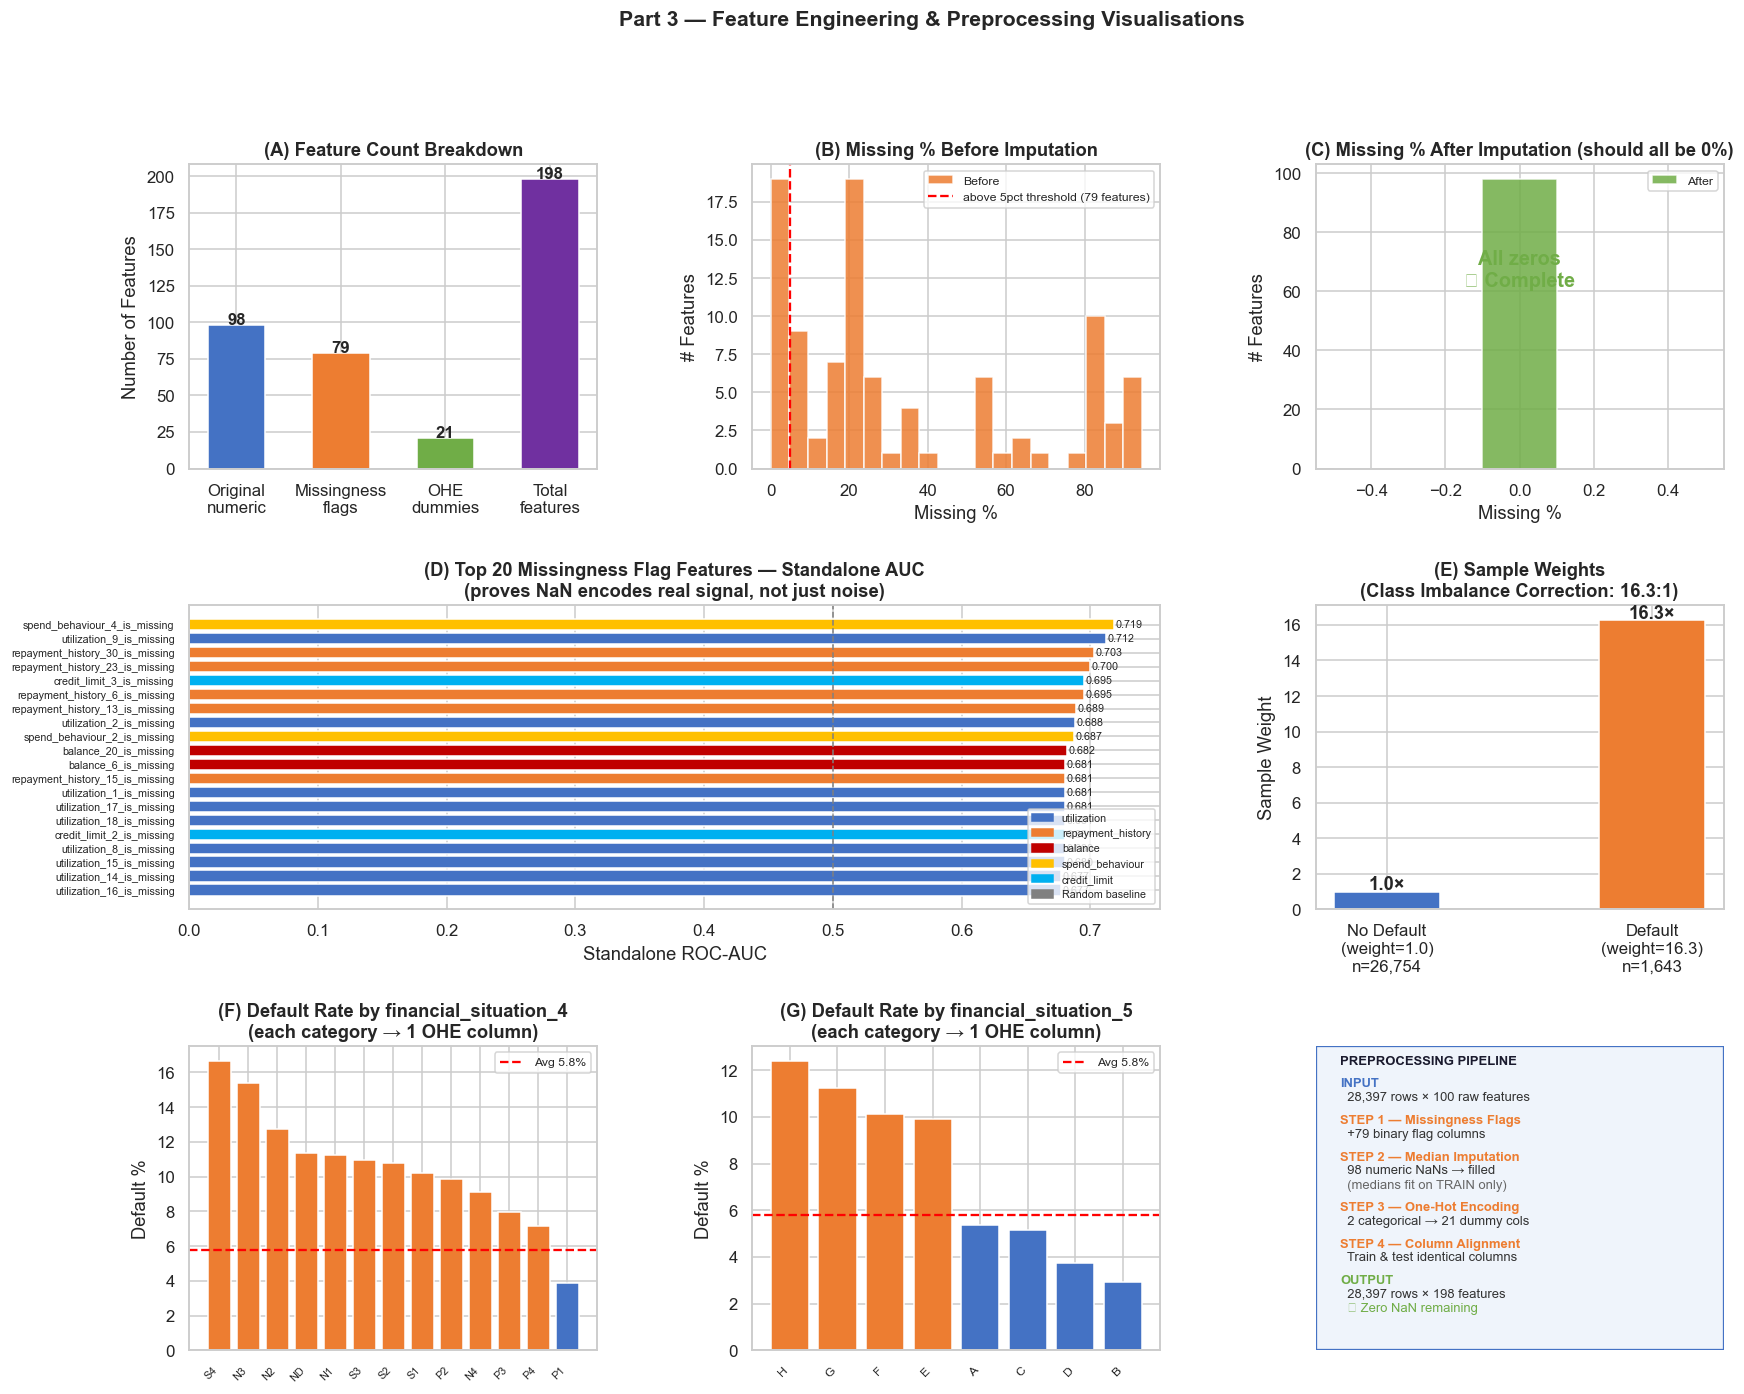

In [17]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Part 3 — Feature Engineering & Preprocessing Visualisations",
             fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── (A) Feature count breakdown ──────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
categories = ["Original\nnumeric", "Missingness\nflags", "OHE\ndummies", "Total\nfeatures"]
values     = [len(num_cols), n_flags, n_dummies, len(feature_cols_final)]
bar_colors = [BLUE, ORANGE, GREEN, PURPLE]
bars = ax.bar(categories, values, color=bar_colors, edgecolor="white", width=0.55)
ax.set_title("(A) Feature Count Breakdown", fontweight="bold")
ax.set_ylabel("Number of Features")
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            str(val), ha="center", fontsize=11, fontweight="bold")

# ── (B) Missing value % — before imputation (histogram) ──────────
ax = fig.add_subplot(gs[0, 1])
miss_before = X_train_raw[num_cols].isnull().mean()*100
ax.hist(miss_before.values, bins=20, color=ORANGE, edgecolor="white", alpha=0.85, label="Before")
thresh_label = f"above 5pct threshold ({len(flag_cols)} features)"
ax.axvline(5, color="red", linestyle="--", lw=1.5, label=thresh_label)
ax.set_title("(B) Missing % Before Imputation", fontweight="bold")
ax.set_xlabel("Missing %"); ax.set_ylabel("# Features")
ax.legend(fontsize=8)

# ── (C) Missing % — after imputation (should be zero for numeric) ─
ax = fig.add_subplot(gs[0, 2])
# For processed train, check residual NaN in original num cols
miss_after = pd.DataFrame(X_train, columns=feature_cols_final)[num_cols].isnull().mean()*100
ax.hist(miss_after.values, bins=5, color=GREEN, edgecolor="white", alpha=0.85, label="After")
ax.set_title("(C) Missing % After Imputation (should all be 0%)", fontweight="bold")
ax.set_xlabel("Missing %"); ax.set_ylabel("# Features")
ax.legend(fontsize=8)
ax.text(0.5, 0.6, "All zeros\n✓ Complete", transform=ax.transAxes,
        ha="center", fontsize=13, color=GREEN, fontweight="bold")

# ── (D) Top 20 missingness flags — AUC as standalone predictors ──
ax = fig.add_subplot(gs[1, 0:2])
flag_aucs = []
for col in flag_cols:
    flag_col = f"{col}_is_missing"
    if flag_col in feature_cols_final:
        auc_pos = roc_auc_score(y_train, train_proc[flag_col].values)
        auc = max(auc_pos, 1-auc_pos)
        m = re.match(r"^([a-z_]+?)_\d+", col)
        fam = m.group(1) if m else "other"
        flag_aucs.append({"flag": flag_col, "auc": auc, "family": fam})

flag_auc_df = pd.DataFrame(flag_aucs).sort_values("auc", ascending=False).head(20)
fam_color_map = {
    "score": PURPLE, "utilization": BLUE, "repayment_history": ORANGE,
    "recency": GREEN, "balance": RED, "spend_behaviour": "#FFC000",
    "credit_limit": "#00B0F0", "financial_situation": "#FF69B4"
}
bar_colors_flags = [fam_color_map.get(r["family"], BLUE) for _, r in flag_auc_df.iterrows()]
flag_auc_df_sorted = flag_auc_df.sort_values("auc")
bar_colors_sorted  = [fam_color_map.get(r["family"], BLUE) for _, r in flag_auc_df_sorted.iterrows()]
bars = ax.barh(flag_auc_df_sorted["flag"], flag_auc_df_sorted["auc"],
               color=bar_colors_sorted, edgecolor="white")
ax.axvline(0.5, color="gray", linestyle="--", lw=1, label="Random (AUC=0.5)")
ax.set_title("(D) Top 20 Missingness Flag Features — Standalone AUC\n"
             "(proves NaN encodes real signal, not just noise)", fontweight="bold")
ax.set_xlabel("Standalone ROC-AUC")
ax.tick_params(axis="y", labelsize=7)
legend_patches = [mpatches.Patch(color=c, label=f) for f, c in fam_color_map.items() if f in flag_auc_df["family"].values]
ax.legend(handles=legend_patches + [mpatches.Patch(color="gray", label="Random baseline")],
          fontsize=7, loc="lower right")
for bar, (_, row) in zip(bars, flag_auc_df_sorted.iterrows()):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f"{row['auc']:.3f}", va="center", fontsize=7)

# ── (E) Sample weights visualisation ─────────────────────────────
ax = fig.add_subplot(gs[1, 2])
weight_counts = {f"No Default\n(weight=1.0)\nn={neg:,}": 1.0,
                 f"Default\n(weight={neg/pos:.1f})\nn={pos:,}": neg/pos}
bars = ax.bar(weight_counts.keys(), weight_counts.values(),
              color=[BLUE, ORANGE], edgecolor="white", width=0.4)
ax.set_title(f"(E) Sample Weights\n(Class Imbalance Correction: {neg/pos:.1f}:1)",
             fontweight="bold")
ax.set_ylabel("Sample Weight")
for bar, val in zip(bars, weight_counts.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f"{val:.1f}×", ha="center", fontsize=12, fontweight="bold")

# ── (F) OHE: default rate per category (both cat features) ───────
ax = fig.add_subplot(gs[2, 0])
col = cat_cols[0]
dr  = (train.groupby(col)["label"].agg(["mean","count"]).reset_index()
           .assign(dr=lambda x: x["mean"]*100).sort_values("dr", ascending=False))
ax.bar(dr[col].astype(str), dr["dr"],
       color=[ORANGE if v>train["label"].mean()*100 else BLUE for v in dr["dr"].values],
       edgecolor="white")
ax.axhline(train["label"].mean()*100, color="red", linestyle="--", lw=1.5,
           label=f"Avg {train['label'].mean()*100:.1f}%")
ax.set_title(f"(F) Default Rate by {col}\n(each category → 1 OHE column)", fontweight="bold")
ax.set_ylabel("Default %"); ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)

ax = fig.add_subplot(gs[2, 1])
col = cat_cols[1]
dr  = (train.groupby(col)["label"].agg(["mean","count"]).reset_index()
           .assign(dr=lambda x: x["mean"]*100).sort_values("dr", ascending=False))
ax.bar(dr[col].astype(str), dr["dr"],
       color=[ORANGE if v>train["label"].mean()*100 else BLUE for v in dr["dr"].values],
       edgecolor="white")
ax.axhline(train["label"].mean()*100, color="red", linestyle="--", lw=1.5,
           label=f"Avg {train['label'].mean()*100:.1f}%")
ax.set_title(f"(G) Default Rate by {col}\n(each category → 1 OHE column)", fontweight="bold")
ax.set_ylabel("Default %"); ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

# ── (H) Pipeline flow diagram (text-based) ───────────────────────
ax = fig.add_subplot(gs[2, 2])
ax.axis("off")
ax.add_patch(plt.Rectangle((0,0),1,1, transform=ax.transAxes,
                             facecolor="#EFF4FB", edgecolor=BLUE, lw=1.5))
steps_text = [
    ("PREPROCESSING PIPELINE", True, "#1a1a2e"),
    ("", False, ""),
    ("INPUT", True, BLUE),
    ("  28,397 rows × 100 raw features", False, "#333"),
    ("", False, ""),
    ("STEP 1 — Missingness Flags", True, ORANGE),
    (f"  +79 binary flag columns", False, "#333"),
    ("", False, ""),
    ("STEP 2 — Median Imputation", True, ORANGE),
    ("  98 numeric NaNs → filled", False, "#333"),
    ("  (medians fit on TRAIN only)", False, "#666"),
    ("", False, ""),
    ("STEP 3 — One-Hot Encoding", True, ORANGE),
    ("  2 categorical → 21 dummy cols", False, "#333"),
    ("", False, ""),
    ("STEP 4 — Column Alignment", True, ORANGE),
    ("  Train & test identical columns", False, "#333"),
    ("", False, ""),
    ("OUTPUT", True, GREEN),
    ("  28,397 rows × 198 features", False, "#333"),
    ("  ✓ Zero NaN remaining", False, GREEN),
]
y_pos = 0.97
for text, bold, color in steps_text:
    if not text: y_pos -= 0.028; continue
    ax.text(0.06, y_pos, text, transform=ax.transAxes,
            fontsize=8.5, fontweight="bold" if bold else "normal",
            color=color or "#333", va="top")
    y_pos -= 0.046

plt.tight_layout(); plt.show()

---
## 10 — Save Preprocessing Artefacts

We save everything needed to replicate the preprocessing on new data:
- `preprocessing_meta.pkl` — all fitted params (medians, modes, column lists)
- This file is loaded by the **inference script** in Part 4 to score holdout data

In [18]:
# ── Build the meta dict ───────────────────────────────────────────
preprocessing_meta = {
    "num_cols"          : num_cols,
    "cat_cols"          : cat_cols,
    "flag_cols"         : flag_cols,
    "feature_cols_final": feature_cols_final,
    "medians"           : train_medians.to_dict(),
    "modes"             : modes,
    "missing_threshold" : 0.05,
    "neg_pos_ratio"     : float(neg / pos),
    "n_train"           : int(len(train)),
    "n_features_final"  : int(len(feature_cols_final)),
}

# ── Save with joblib ──────────────────────────────────────────────
joblib.dump(preprocessing_meta, "preprocessing_meta.pkl")

# ── Also save a human-readable JSON summary ───────────────────────
meta_json = {k: v for k, v in preprocessing_meta.items()
             if k not in ["medians"]}   # medians too large for clean JSON
meta_json["n_flag_cols"]   = len(flag_cols)
meta_json["n_dummy_cols"]  = n_dummies
meta_json["n_num_cols"]    = len(num_cols)
with open("preprocessing_meta_summary.json", "w") as f:
    json.dump(meta_json, f, indent=2)

print("✓ Saved: preprocessing_meta.pkl")
print("✓ Saved: preprocessing_meta_summary.json")
print()
print("Contents of preprocessing_meta:")
for k, v in preprocessing_meta.items():
    if isinstance(v, list):
        print(f"  {k:<25}: list of {len(v)} items")
    elif isinstance(v, dict):
        print(f"  {k:<25}: dict with {len(v)} keys")
    else:
        print(f"  {k:<25}: {v}")

✓ Saved: preprocessing_meta.pkl
✓ Saved: preprocessing_meta_summary.json

Contents of preprocessing_meta:
  num_cols                 : list of 98 items
  cat_cols                 : list of 2 items
  flag_cols                : list of 79 items
  feature_cols_final       : list of 198 items
  medians                  : dict with 98 keys
  modes                    : dict with 2 keys
  missing_threshold        : 0.05
  neg_pos_ratio            : 16.283627510651247
  n_train                  : 28397
  n_features_final         : 198


In [19]:
# ── Quick sanity check: reload and re-apply ───────────────────────
meta_reload = joblib.load("preprocessing_meta.pkl")

# Re-run preprocessing using loaded meta
test_reload, _, _, _ = preprocess(
    test,
    num_cols  = meta_reload["num_cols"],
    cat_cols  = meta_reload["cat_cols"],
    flag_cols = meta_reload["flag_cols"],
    fit_medians      = pd.Series(meta_reload["medians"]),
    fit_modes        = meta_reload["modes"],
    fit_feature_cols = meta_reload["feature_cols_final"]
)
X_test_reload = test_reload[meta_reload["feature_cols_final"]].values.astype(np.float32)

# Check identical
assert np.allclose(X_test, X_test_reload, equal_nan=True), "Reload mismatch!"
print("✓ Reload check passed — preprocessing_meta.pkl produces identical output")
print(f"  X_test shape: {X_test_reload.shape}")

✓ Reload check passed — preprocessing_meta.pkl produces identical output
  X_test shape: (4000, 198)


---
## 11 — Summary

| Step | Action | Before | After |
|---|---|---|---|
| **1. Missingness flags** | Binary indicator per feature with >5% NaN | 98 numeric cols | +79 flag cols |
| **2. Median imputation** | Fill NaN with train median | Up to 94% missing in some cols | 0% missing |
| **3. One-hot encoding** | Encode 2 categorical features | 2 string cols | +21 dummy cols |
| **4. Column alignment** | Ensure test has same columns as train | Potential mismatch | Guaranteed alignment |
| **5. Sample weights** | Weight default rows by 16.3× | 5.8% default rate imbalance | Balanced loss function |

### Final feature matrix
| | Shape | NaN | Default rate |
|---|---|---|---|
| **X_train** | 28,397 × 198 | 0 | 5.79% |
| **X_test** | 4,000 × 198 | 0 | 5.85% |

### Feature breakdown: 198 total
- **98** original numeric features
- **79** missingness indicator flags (new engineered features)
- **21** one-hot dummy columns (from 2 categorical features)

### Key design principles
- **No leakage**: all fit parameters (medians, column lists) derived from train set only
- **NaN as signal**: missingness flags preserve information instead of discarding it
- **Reusable pipeline**: `preprocess()` + `preprocessing_meta.pkl` can score any new dataset

### → Part 4: Model Training, Comparison & Selection
- Logistic Regression (baseline ML)
- Random Forest
- Gradient Boosting Machine
- Select best by ROC-AUC + CV AUC